## Movies Dataset 2024 - Grupo 9
<hr style="border:1px solid gray">

# 1. Configuración inicial

## 1.1 Correr con UV

```shell
uv sync
uv run jupyter lab
```

## 1.2 Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

## 1.3 Importart dataset

In [2]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

100%|██████████| 241M/241M [00:03<00:00, 83.7MB/s]

Extracting files...


Dataset copied to: data/TMDB_movie_dataset_v11.csv


## 1.4 Carga del dataset

In [3]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
movies = pd.read_csv(data_path)

# 2. Descripción del dataset IMDB Movies 2024


| Variable              | Descripción                                                                                  |
|-----------------------|----------------------------------------------------------------------------------------------|
| `id`                  | Unique identifier for each movie. (type: int)                                                |
| `title`               | Title of the movie (usually in English or the display title). (type: str)                    |
| `vote_average`        | Average vote or rating given by viewers (typically 0–10 scale). (type: float)                |
| `vote_count`          | Total count of votes received for the movie. (type: int)                                     |
| `status`              | Current status of the movie (Released, Rumored, Post Production, etc.). (type: str)          |
| `release_date`        | Date when the movie was released (format usually YYYY-MM-DD). (type: str)                    |
| `revenue`             | Total revenue generated by the movie (in USD; 0 often means unknown/missing). (type: int)    |
| `runtime`             | Duration of the movie in minutes (0 usually means unknown). (type: int)                      |
| `adult`               | Indicates if the movie is only for adult audiences (true/false). (type: bool)                |
| `backdrop_path`       | Relative path to the backdrop image for the movie . (type: str)                              |
| `budget`              | Estimated production budget of the movie (USD; 0 often means unknown/missing). (type: int64) |
| `homepage`            | Official website URL of the movie (empty string or null if not available). (type: str)       |
| `imdb_id`             | IMDb identifier for the movie (format: tt followed by 7–8 digits). (type: str)               |
| `original_language`   | ISO 639-1 code of the original language of the movie (e.g., 'en', 'fr', 'es'). (type: str)   |
| `original_title`      | Original title of the movie (in its original language). (type: str)                          |
| `overview`            | Brief plot summary or synopsis of the movie. (type: str)                                     |
| `popularity`          | Popularity score assigned by TMDB (higher = more popular). (type: float64)                   |
| `poster_path`         | Relative path to the poster image for the movie (prepend https://image.tmdb.org) (type: str) |
| `tagline`             | Short marketing tagline or slogan of the movie (often empty). (type: str)                    |
| `genres`              | List of genres (usually as comma-separated string or JSON in some datasets). (type: str)     |
| `production_companies`| Name(s) of the main production company/companies (often comma-separated or JSON) (type: str) |
| `production_countries`| Country/countries where the movie was produced (often comma-separated or JSON). (type: str)  |
| `spoken_languages`    | Language(s) spoken in the movie (comma-separated or JSON. ISO codes and names). (type: str)  |
| `keywords`            | Descriptive keywords/tags linked with the movie (often comma-separated or JSON). (type: str) |

# 3. Primera inspección

## 3.1 Dimensiones del dataset original

In [4]:
print(f"Dimensiones del dataset original: {movies.shape}")
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
movies[columns].head()

Dimensiones del dataset original: (1407834, 24)


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407834 entries, 0 to 1407833
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1407834 non-null  int64  
 1   title                 1407816 non-null  object 
 2   vote_average          1407834 non-null  float64
 3   vote_count            1407834 non-null  int64  
 4   status                1407834 non-null  object 
 5   release_date          1098035 non-null  object 
 6   revenue               1407834 non-null  int64  
 7   runtime               1407834 non-null  int64  
 8   adult                 1407834 non-null  bool   
 9   backdrop_path         350572 non-null   object 
 10  budget                1407834 non-null  int64  
 11  homepage              144984 non-null   object 
 12  imdb_id               665745 non-null   object 
 13  original_language     1407834 non-null  object 
 14  original_title        1407816 non-

In [6]:
movies[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.407834e+06,1.407834e+06,1.407834e+06,1.407834e+06,1.407834e+06,1.407834e+06
mean,1.565571e+00,1.524135e+01,6.217312e+05,4.410255e+01,2.369824e+05,1.019442e+00
std,2.863560e+00,2.862895e+02,1.931591e+07,6.068474e+01,5.091466e+06,6.832812e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.710000e-02
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.100000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


## 3.2 Análisis de las variables numéricas

#### Nota: hay columnas con muchos valores en 0
IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:
- `field_valid = movies['field'][movies['field'] > 0]` # subset de valores mayores a 0
- `movies['field'].replace(0, np.nan).mode()` # reemplazar 0 por NaN

In [7]:
movies['budget'].median() # example w/o filtering 0s

0.0

In [8]:
budget_valid = movies['budget'][movies['budget'] > 0]
budget_valid.median() # iltering 0s

3000.0

In [9]:
movies['popularity'].mean() # example w/o filtering 0s

np.float64(1.0194424837323557)

In [10]:
movies['popularity'].replace(0, np.nan).mean() # example filtering 0s

np.float64(1.2249138114132432)

#### Definir sets válidos

In [11]:
budget_valid = movies['budget'][movies['budget'] > 0]
revenue_valid = movies['revenue'][movies['revenue'] != 0] # movie can also lose money
popularity_valid = movies['popularity'][movies['popularity'] > 0]
vote_count_valid = movies['vote_count'][movies['vote_count'] > 0]
vote_average_valid = movies['vote_average'][movies['vote_average'] > 0]
runtime_valid = movies['runtime'][movies['runtime'] > 0]

#### Max/Mins

In [12]:
# Maximum budget
max_budget = budget_valid.max()
print(f"Maximum budget: ${max_budget:,}")

# Minimum budget
min_budget = budget_valid.min()
print(f"Minimum budget: ${min_budget:,}")

# Maximum revenue
max_revenue = revenue_valid.max()
print(f"Maximum revenue: ${max_revenue:,}")

# Minimum revenue
min_revenue = revenue_valid.min()
print(f"Minimum revenue: ${min_revenue:,}")

# Maximum popularity
max_popularity = popularity_valid.replace(0, np.nan).max()
print(f"Maximum popularity: {max_popularity:,}")

# Minimum popularity
min_popularity = popularity_valid.replace(0, np.nan).min()
print(f"Minimum popularity: {min_popularity:,}")

# Maximum vote_average
max_vote_average = vote_average_valid.replace(0, np.nan).max()
print(f"Maximum vote_average: {max_vote_average:,}")

# Minimum vote_average
min_vote_average = vote_average_valid.replace(0, np.nan).min()
print(f"Minimum vote_average: {min_vote_average:,}")

# Maximum vote_count
max_vote_count = vote_count_valid.replace(0, np.nan).max()
print(f"Maximum vote_count: {max_vote_count:,}")

# Minimum vote_count
min_vote_count = vote_count_valid.replace(0, np.nan).min()
print(f"Minimum vote_count: {min_vote_count:,}")

# Maximum runtime
max_runtime = runtime_valid.replace(0, np.nan).max()
print(f"Maximum runtime: {max_runtime:,}")

# Minimum vote_count
min_runtime = runtime_valid.replace(0, np.nan).min()
print(f"Minimum runtime: {min_runtime:,}")

Maximum budget: $999,999,999
Minimum budget: $1
Maximum revenue: $4,999,999,999
Minimum revenue: $-12
Maximum popularity: 2,994.357
Minimum popularity: 0.0071
Maximum vote_average: 10.0
Minimum vote_average: 0.5
Maximum vote_count: 34,495
Minimum vote_count: 1
Maximum runtime: 14,400
Minimum runtime: 1


## 3.3 Histogramas

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


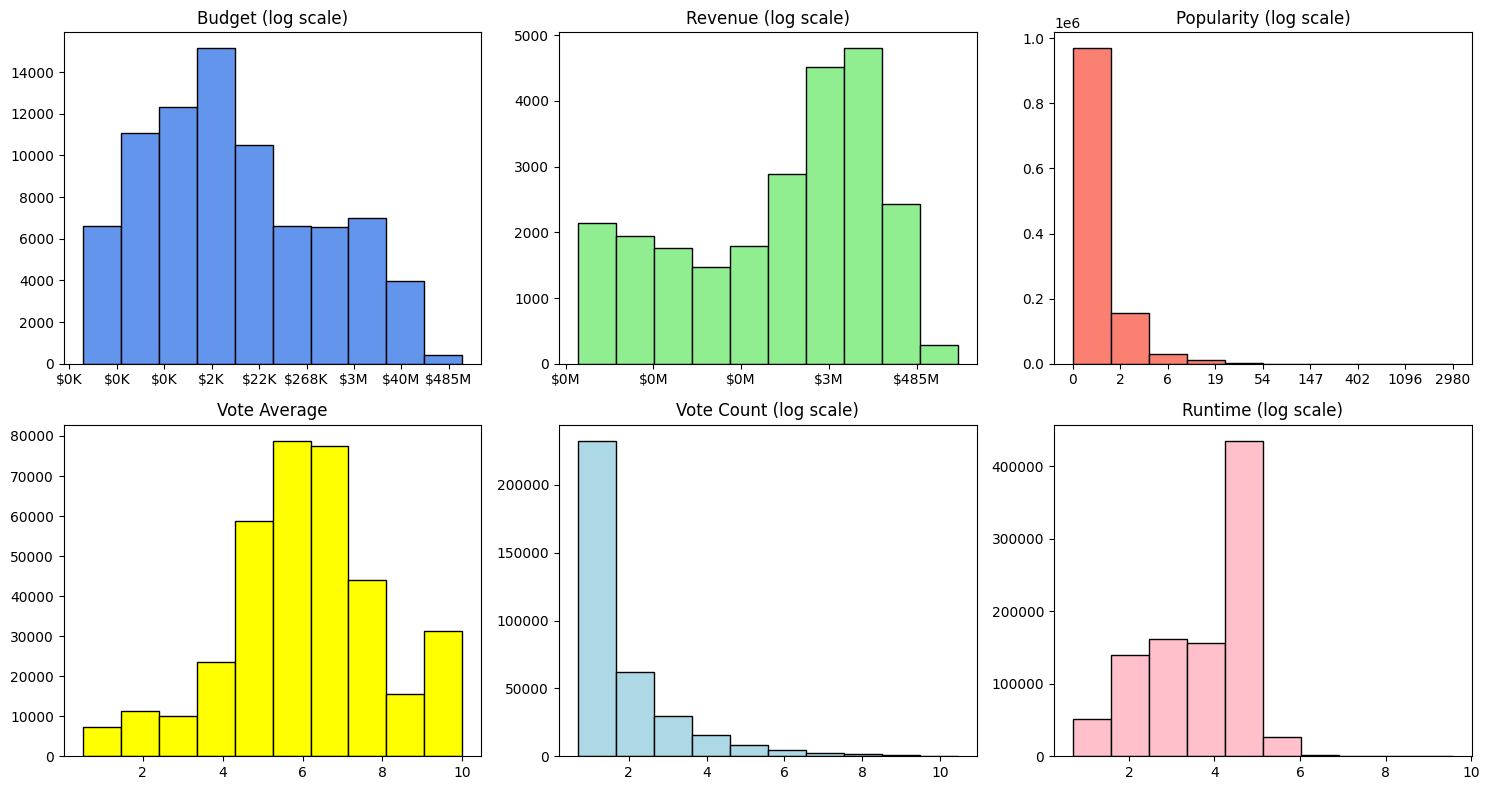

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# --- Budget ---
ax[0,0].hist(np.log1p(budget_valid), bins=10, color='cornflowerblue', edgecolor='black')
ax[0,0].set_title('Budget (log scale)')

# Nice original-scale tick labels
def log1p_inverse(y):
    return np.expm1(y)

ax[0,0].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M" if y >= 13 else f"${log1p_inverse(y)/1e3:.0f}K"
))

# --- Revenue ---
# valid_revenue = movies['revenue'][movies['revenue'] > 0]  # also drop negative
ax[0,1].hist(np.log1p(revenue_valid), bins=10, color='lightgreen', edgecolor='black')
ax[0,1].set_title('Revenue (log scale)')
ax[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"${log1p_inverse(y)/1e6:.0f}M"
))

# --- Popularity ---
ax[0,2].hist(np.log1p(popularity_valid), bins=10, color='salmon', edgecolor='black')
ax[0,2].set_title('Popularity (log scale)')
ax[0,2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, pos: f"{log1p_inverse(y):.0f}"
))

# --- Vote Average ---
ax[1,0].hist(vote_average_valid, bins=10, color='yellow', edgecolor='black')
ax[1,0].set_title('Vote Average')

# --- Vote Count ---
ax[1,1].hist(np.log1p(vote_count_valid), bins=10, color='lightblue', edgecolor='black')
ax[1,1].set_title('Vote Count (log scale)')

# --- Rubntime ---
ax[1,2].hist(np.log1p(runtime_valid), bins=10, color='pink', edgecolor='black')
ax[1,2].set_title('Runtime (log scale)')

plt.tight_layout()
plt.show()

### Movies per month
<hr style="border:1px solid gray">


Standarize dates:

In [14]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

Visualize:

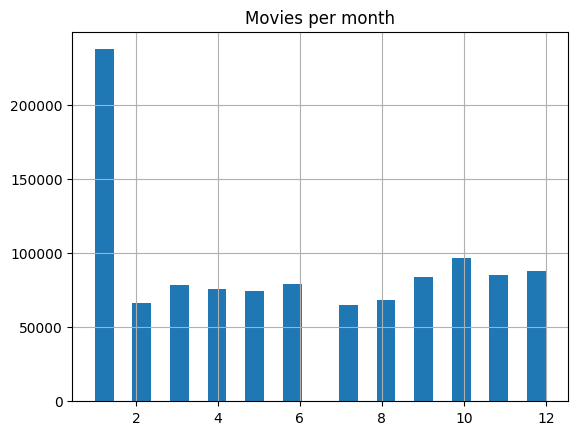

In [15]:
movies['release_month'] = movies['release_date'].dt.month
ax = movies['release_month'].hist(bins=24)
ax.set_title('Movies per month')
plt.show()

### 1. Medidas de tendencia central: media, mediana y moda
<hr style="border:1px solid gray">


#### Media

In [16]:
np.mean(budget_valid.replace(0, np.nan))    # Budget

np.float64(4159117.368400713)

In [17]:
np.mean(revenue_valid.replace(0, np.nan)) # Revenue

np.float64(36361510.303049184)

In [18]:
np.mean(popularity_valid) # Popularity

np.float64(1.2249138114132427)

In [19]:
np.mean(vote_count_valid.replace(0, np.nan)) # Vote count

np.float64(59.87553192973644)

In [20]:
np.mean(vote_average_valid.replace(0, np.nan)) # Vote average

np.float64(6.155109191341768)

In [21]:
np.mean(runtime_valid.replace(0, np.nan)) # Runtime

np.float64(63.749327742395195)

#### Mediana

In [22]:
np.median(budget_valid.replace(0, np.nan))  # Budget

np.float64(3000.0)

In [23]:
np.median(revenue_valid) # Revenue

np.float64(877551.0)

In [24]:
np.median(popularity_valid) # Popularity

np.float64(0.6)

In [25]:
np.median(vote_count_valid) # Vote count

np.float64(2.0)

In [26]:
np.median(vote_average_valid) # Vote average

np.float64(6.0)

In [27]:
np.median(runtime_valid) # Runtime

np.float64(62.0)

#### Moda

In [28]:
budget_valid.mode()[0]     # Budget

np.int64(100)

In [29]:
revenue_valid.mode()[0]     # Revenue

np.int64(1)

In [30]:
popularity_valid.mode()[0]     # Popularity

np.float64(0.6)

In [31]:
vote_count_valid.mode()[0]     # Vote count

np.int64(1)

In [32]:
vote_average_valid.mode()[0]     # Vote average

np.float64(6.0)

In [33]:
runtime_valid.mode()[0]     # Runtime

np.int64(90)

# 4. Análisis de inconsistencias

## 4.1 Películas duplicadas

In [34]:
# Dataset information
print(f"Amount of movies (rows): {len(movies)}")
print(f"Amount of unique movies: {movies['id'].nunique()}")
print(f"Amount of columns: {len(movies.columns)}")

# Check for duplicate IDs
duplicate_ids = movies['id'].duplicated().sum()
if duplicate_ids > 0:
    print(f"\n Found {duplicate_ids} duplicate movie IDs!")
else:
    print("\nAll movie IDs are unique")

Amount of movies (rows): 1407834
Amount of unique movies: 1406601
Amount of columns: 25

 Found 1233 duplicate movie IDs!


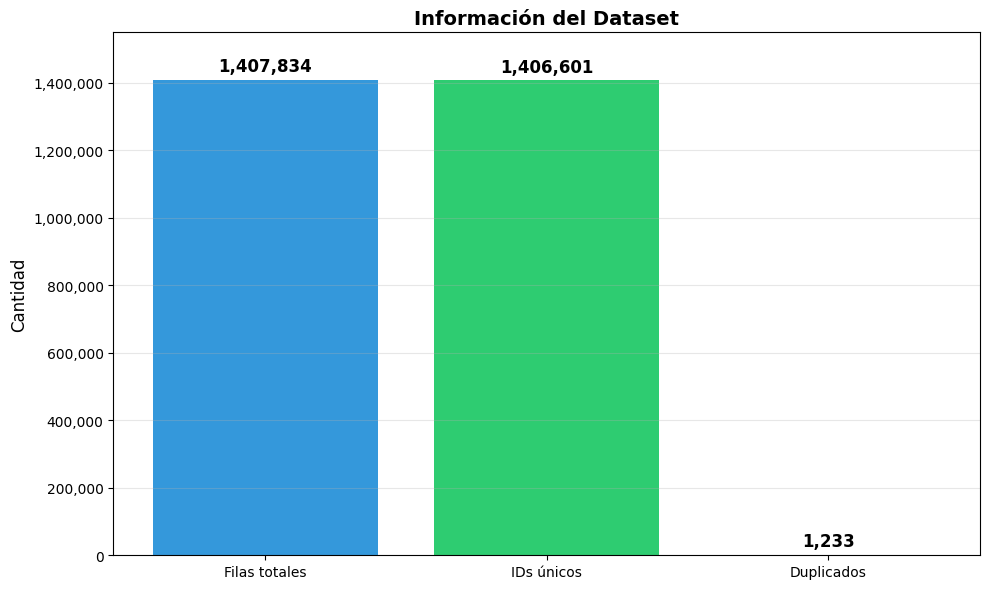

In [35]:
# Visualizar información del dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Datos
categorias = ['Filas totales', 'IDs únicos', 'Duplicados']
valores = [len(movies), movies['id'].nunique(), len(movies) - movies['id'].nunique()]
colores = ['#3498db', '#2ecc71', '#e74c3c']

# Crear gráfico de barras
bars = ax.bar(categorias, valores, color=colores)

# Configurar etiquetas y título
ax.set_title('Información del Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad', fontsize=12)

# Formatear el eje Y para mostrar valores completos
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Ajustar escala del eje Y
max_val = max(valores)
ax.set_ylim(0, max_val * 1.1)

# Agregar valores sobre las barras
for bar, valor in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max_val * 0.01,
             f'{valor:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Agregar grid para mejor lectura
ax.grid(axis='y', alpha=0.3)

# Rotar etiquetas si es necesario
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# remove duplicates
movies = movies.drop_duplicates(subset=['id'], keep='first')

# 5. Análisis de variables categóricas



Analizamos algunas variables categóricas del dataset como idioma original, géneros y países de producción para entender su distribución dentro del dataset.



In [37]:
# Lista de columnas categóricas relevantes del dataset
categorical_columns = [
    "original_language",
    "genres",
    "production_countries",
    "production_companies",
    "keywords"
]

# Mostrar ejemplos de estas columnas
movies[categorical_columns].head()

,original_language,genres,production_countries,production_companies,keywords
0,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict...","rescue, mission, dream, airplane, paris, franc..."
1,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc...","rescue, future, spacecraft, race against time,..."
2,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel...","joker, sadism, chaos, secret identity, crime f..."
3,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ...","future, society, culture clash, space travel, ..."
4,en,"Science Fiction, Action, Adventure",United States of America,Marvel Studios,"new york city, superhero, shield, based on com..."


### Idioma original de las películas

En primer lugar analizamos la variable `original_language`, que indica el idioma original de cada película.

Este análisis permite observar qué idiomas están más representados en el dataset y si existe una concentración importante en algunos idiomas particulares.

Para ello calculamos la cantidad de películas por idioma y visualizamos los más frecuentes mediante un gráfico de barras.

In [38]:
# Contar cuántas películas hay por idioma
language_counts = movies["original_language"].value_counts()

# Cantidad total de idiomas distintos
print("Cantidad de idiomas distintos:", movies["original_language"].nunique())

# Mostrar los 10 idiomas más frecuentes
language_counts.head(10)

Cantidad de idiomas distintos: 177


,count
original_language,
en,769098
fr,81636
es,71558
de,63665
ja,63480
zh,45588
pt,43514
it,28354
ru,28264


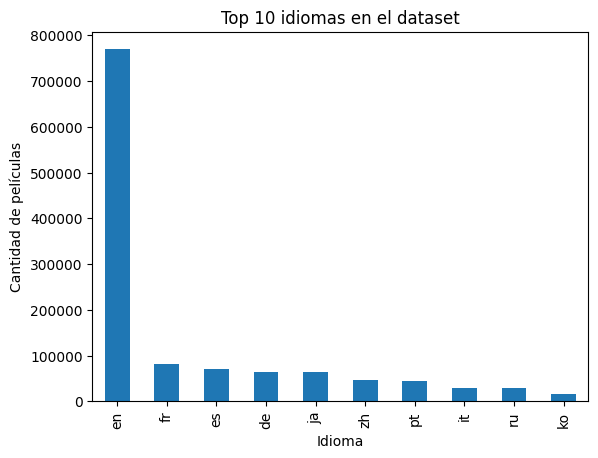

In [39]:
import matplotlib.pyplot as plt

# Gráfico de barras con los idiomas más frecuentes
language_counts.head(10).plot(kind="bar")

plt.title("Top 10 idiomas en el dataset")
plt.xlabel("Idioma")
plt.ylabel("Cantidad de películas")
plt.show()

### Géneros de las películas

La variable `genres` contiene los géneros asociados a cada película. En el dataset esta columna está almacenada como un string separado por comas (por ejemplo: `Action, Science Fiction, Adventure`).

Para poder analizar los géneros de forma individual, primero convertimos este string en una lista y luego utilizamos `explode()` para crear una fila por cada género asociado a una película.

De esta forma podemos calcular la frecuencia de cada género y analizar su popularidad promedio dentro del dataset.

In [40]:
movies["genres"].iloc[0]

'Action, Science Fiction, Adventure'

In [41]:
# La columna genres está almacenada como un string separado por comas
# Ejemplo: "Action, Science Fiction, Adventure"

# Primero convertimos ese string en una lista separando por coma

movies["genres"] = movies["genres"].fillna("").apply(lambda x: [g.strip() for g in x.split(",") if g])

# Ahora cada fila tiene una lista de géneros

movies["genres"].head()

,genres
0,"[Action, Science Fiction, Adventure]"
1,"[Adventure, Drama, Science Fiction]"
2,"[Drama, Action, Crime, Thriller]"
3,"[Action, Adventure, Fantasy, Science Fiction]"
4,"[Science Fiction, Action, Adventure]"


In [42]:
# "Aplanar" la lista de géneros
genres = movies.explode("genres")

# Verificar resultado
genres[["title","genres"]].head()

,title,genres
0,Inception,Action
0,Inception,Science Fiction
0,Inception,Adventure
1,Interstellar,Adventure
1,Interstellar,Drama


In [43]:
# Contar géneros
genre_counts = genres["genres"].value_counts()

genre_counts.head(10)

,count
genres,
Drama,259467
Documentary,196083
Comedy,158105
Animation,66786
Horror,64043
Romance,59798
Music,56557
Thriller,54551
Action,49820


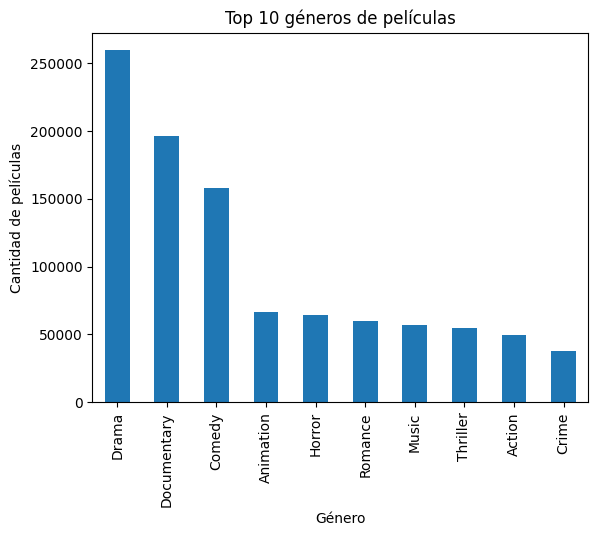

In [44]:
# Visualizar los géneros más frecuentes
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 géneros de películas")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.show()

In [45]:
# Calcular la popularidad promedio para cada género
genre_popularity = genres.groupby("genres")["popularity"].mean().sort_values(ascending=False)

genre_popularity.head(10)

,popularity
genres,
Adventure,4.234261
Action,3.788558
Thriller,3.306327
Science Fiction,3.221364
Fantasy,2.913372
Crime,2.704880
Mystery,2.700375
Family,2.688428
Romance,2.419711


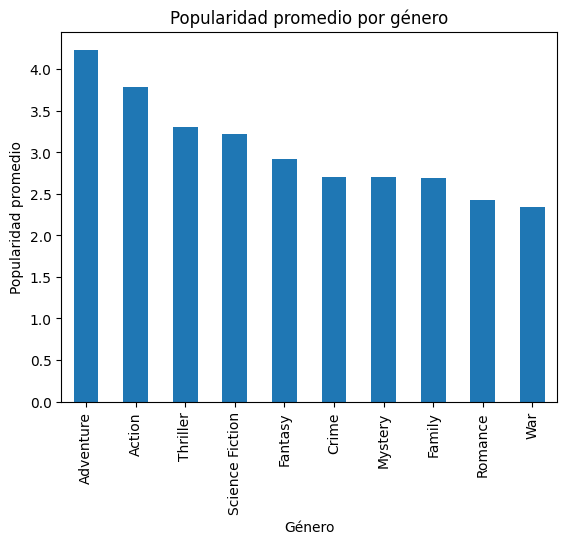

In [46]:
# Visualizar qué géneros tienen mayor popularidad promedio
genre_popularity.head(10).plot(kind="bar")

plt.title("Popularidad promedio por género")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.show()

### Países de producción

También analizamos los países de producción para identificar qué países participan con mayor frecuencia en la producción de películas del dataset.

In [47]:
# La columna production_countries también está almacenada como un string separado por comas
# Convertimos el string en una lista

movies["production_countries"] = movies["production_countries"].fillna("").apply(
    lambda x: [c.strip() for c in x.split(",") if c]
)

movies["production_countries"].head()

,production_countries
0,"[United Kingdom, United States of America]"
1,"[United Kingdom, United States of America]"
2,"[United Kingdom, United States of America]"
3,"[United States of America, United Kingdom]"
4,[United States of America]


In [48]:
# Aplanar la lista de países
countries = movies.explode("production_countries")

countries[["title","production_countries"]].head()

,title,production_countries
0,Inception,United Kingdom
0,Inception,United States of America
1,Interstellar,United Kingdom
1,Interstellar,United States of America
2,The Dark Knight,United Kingdom


In [49]:
# Conteo de países
country_counts = countries["production_countries"].value_counts()

country_counts.head(10)

,count
production_countries,
United States of America,215423
Japan,51280
France,50780
United Kingdom,48140
Germany,47903
Canada,27033
India,23549
Brazil,21555
Italy,20893


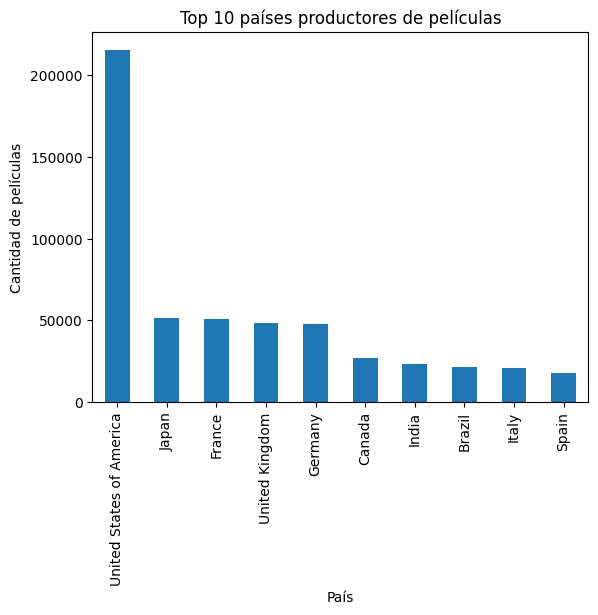

In [50]:
#Gráfico de países
country_counts.head(10).plot(kind="bar")

plt.title("Top 10 países productores de películas")
plt.xlabel("País")
plt.ylabel("Cantidad de películas")
plt.show()

### Productoras

Analizamos las productoras involucradas en las películas para identificar cuáles participan con mayor frecuencia en la producción cinematográfica.

In [51]:
movies["production_companies"].head()

,production_companies
0,"Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,"Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,"DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,"Dune Entertainment, Lightstorm Entertainment, ..."
4,Marvel Studios


In [52]:
# Aplanar la lista de productoras
companies = movies.explode("production_companies")

companies[["title", "production_companies"]].head()

,title,production_companies
0,Inception,"Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,Interstellar,"Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,The Dark Knight,"DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,Avatar,"Dune Entertainment, Lightstorm Entertainment, ..."
4,The Avengers,Marvel Studios


In [53]:
#Conteo de productoras
company_counts = companies["production_companies"].value_counts()

company_counts.head(10)

,count
production_companies,
Evil Angel,3149
ONF | NFB,2435
BBC,2365
Metro-Goldwyn-Mayer,2051
Columbia Pictures,1958
Toei Company,1845
Nikkatsu Corporation,1689
Private,1643
Universal Pictures,1596


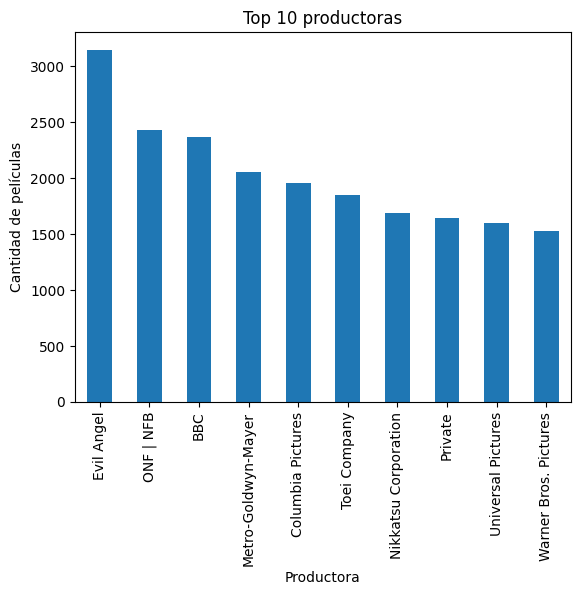

In [54]:
#Gráfico de productoras
company_counts.head(10).plot(kind="bar")

plt.title("Top 10 productoras")
plt.xlabel("Productora")
plt.ylabel("Cantidad de películas")
plt.show()

### Palabras clave (Keywords)

Las palabras clave permiten identificar los temas o conceptos más frecuentes en las películas del dataset.

In [55]:
movies["keywords"].head()

,keywords
0,"rescue, mission, dream, airplane, paris, franc..."
1,"rescue, future, spacecraft, race against time,..."
2,"joker, sadism, chaos, secret identity, crime f..."
3,"future, society, culture clash, space travel, ..."
4,"new york city, superhero, shield, based on com..."


In [56]:
# Aplanar la lista de keywords
companies = movies.explode("keywords")

companies[["title", "keywords"]].head()

,title,keywords
0,Inception,"rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,"rescue, future, spacecraft, race against time,..."
2,The Dark Knight,"joker, sadism, chaos, secret identity, crime f..."
3,Avatar,"future, society, culture clash, space travel, ..."
4,The Avengers,"new york city, superhero, shield, based on com..."


In [57]:
#Conteo de keywords
keyword_counts = companies["keywords"].value_counts()

keyword_counts.head(10)

,count
keywords,
short film,10937
gay pornography,9740
woman director,8375
stand-up comedy,2654
concert,2052
"compilation, gay pornography",1794
based on novel or book,1526
softcore,1477
anal sex,1385


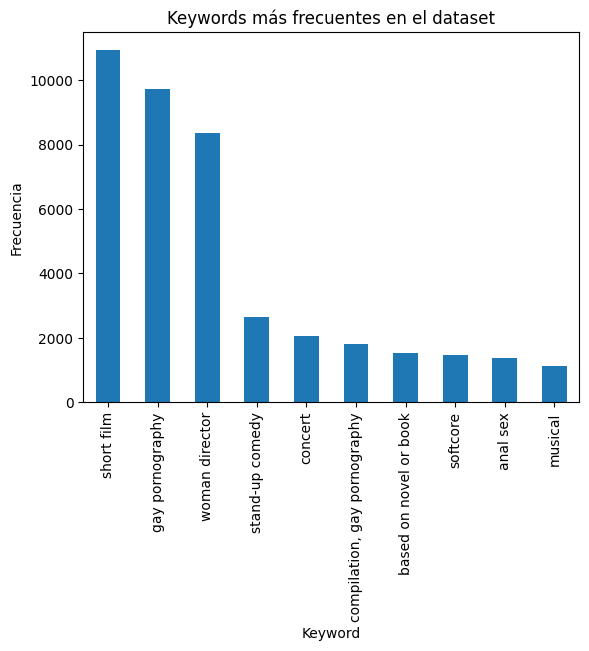

In [58]:
#Gráfico de keywords
keyword_counts.head(10).plot(kind="bar")

plt.title("Keywords más frecuentes en el dataset")
plt.xlabel("Keyword")
plt.ylabel("Frecuencia")
plt.show()

### Hallazgos

El análisis de variables categóricas muestra algunos patrones interesantes en el dataset:

- **Idioma original:** El inglés aparece como el idioma predominante en el dataset, lo cual es consistente con la fuerte presencia de producciones de la industria cinematográfica estadounidense. Otros idiomas aparecen con una frecuencia considerablemente menor.

- **Géneros:** Los géneros más frecuentes en el dataset son *Drama*, *Documentary* y *Comedy*. Esto indica que una gran parte del conjunto de películas analizadas pertenece a categorías narrativas o documentales, mientras que otros géneros aparecen con menor frecuencia.

- **Popularidad por género:** Al analizar la popularidad promedio por género se observa que *Adventure* y *Action* presentan los valores más altos de popularidad promedio. Esto sugiere que, aunque no sean los géneros más numerosos en el dataset, este tipo de películas tiende a generar mayor interés o visibilidad.

- **Países de producción:** La producción cinematográfica del dataset está fuertemente concentrada en algunos países. *United States of America* aparece como el principal país productor, seguido por *Japan*, *France* y *United Kingdom*. Esto refleja el peso de estas industrias cinematográficas dentro del conjunto de datos analizado.

- **Productoras:** Algunas compañías aparecen con mayor frecuencia dentro del dataset, lo que indica que ciertas productoras participan en múltiples proyectos y tienen un rol importante dentro del conjunto de películas analizado. Entre las productoras con mayor cantidad de películas se encuentran *BBC*, *Warner Bros. Pictures*, *Columbia Pictures* y *Universal Pictures*.

- **Palabras clave:** El análisis de keywords muestra que existen ciertos temas o características recurrentes en las películas del dataset. Entre las más frecuentes aparecen términos relacionados con formatos de producción (por ejemplo *short film*), características de dirección (*woman director*) o el origen de la obra (*based on novel or book*). Esto sugiere que el dataset incluye una amplia variedad de producciones y temáticas

En conjunto, el análisis de estas variables permite comprender mejor la estructura del dataset y las características principales de las películas incluidas. A su vez, el proceso de conversión de strings a listas y el uso de `explode()` permitió analizar correctamente estas variables categóricas.

# 5. Análisis de Calidad de Datos y Preparación para ML

En esta sección, realizaremos un análisis formal de la calidad de los datos, clasificando los valores faltantes y detectando valores atípicos. Además, prepararemos el dataset filtrando aquellas películas con pocos votos para asegurar la confiabilidad de nuestra variable objetivo: `vote_average`.

### 5.1 Clasificación de Valores Faltantes

Identificamos las columnas con valores nulos y los clasificamos según su naturaleza:

- **MCAR (Missing Completely at Random):** Los valores faltantes no dependen de ninguna otra variable. Ejemplo: `runtime` (pueden ser omisiones aleatorias en la carga).
- **MAR (Missing at Random):** La probabilidad de que falte un dato depende de otras variables observadas. Ejemplo: `tagline` o `keywords` (películas menos populares o producciones independientes suelen carecer de estos metadatos con más frecuencia).
- **MNAR (Missing Not at Random):** Los valores faltantes dependen del valor del propio dato faltante. Ejemplo: `revenue` o `budget` (películas con menor éxito financiero podrían omitir reportar estos datos).

In [59]:
# Resumen de valores nulos
missing_values = movies.isnull().sum()
missing_percent = (missing_values / len(movies)) * 100
missing_df = pd.DataFrame({'Nulos': missing_values, 'Porcentaje': missing_percent})
print("Columnas con valores nulos:")
print(missing_df[missing_df['Nulos'] > 0].sort_values(by='Porcentaje', ascending=False))

Columnas con valores nulos:
                        Nulos  Porcentaje
homepage              1261720   89.699922
tagline               1210778   86.078284
keywords              1057613   75.189268
backdrop_path         1056144   75.084832
production_companies   806212   57.316325
imdb_id                741205   52.694758
spoken_languages       651304   46.303394
poster_path            497521   35.370443
overview               321377   22.847773
release_month          308998   21.967708
release_date           308998   21.967708
title                      18    0.001280
original_title             18    0.001280


### 5.2 Detección de Outliers

Visualizamos la distribución de las variables numéricas clave para identificar valores atípicos. Variables como `popularity` y `vote_count` suelen tener distribuciones de "cola larga" donde unos pocos blockbusters tienen valores masivos.

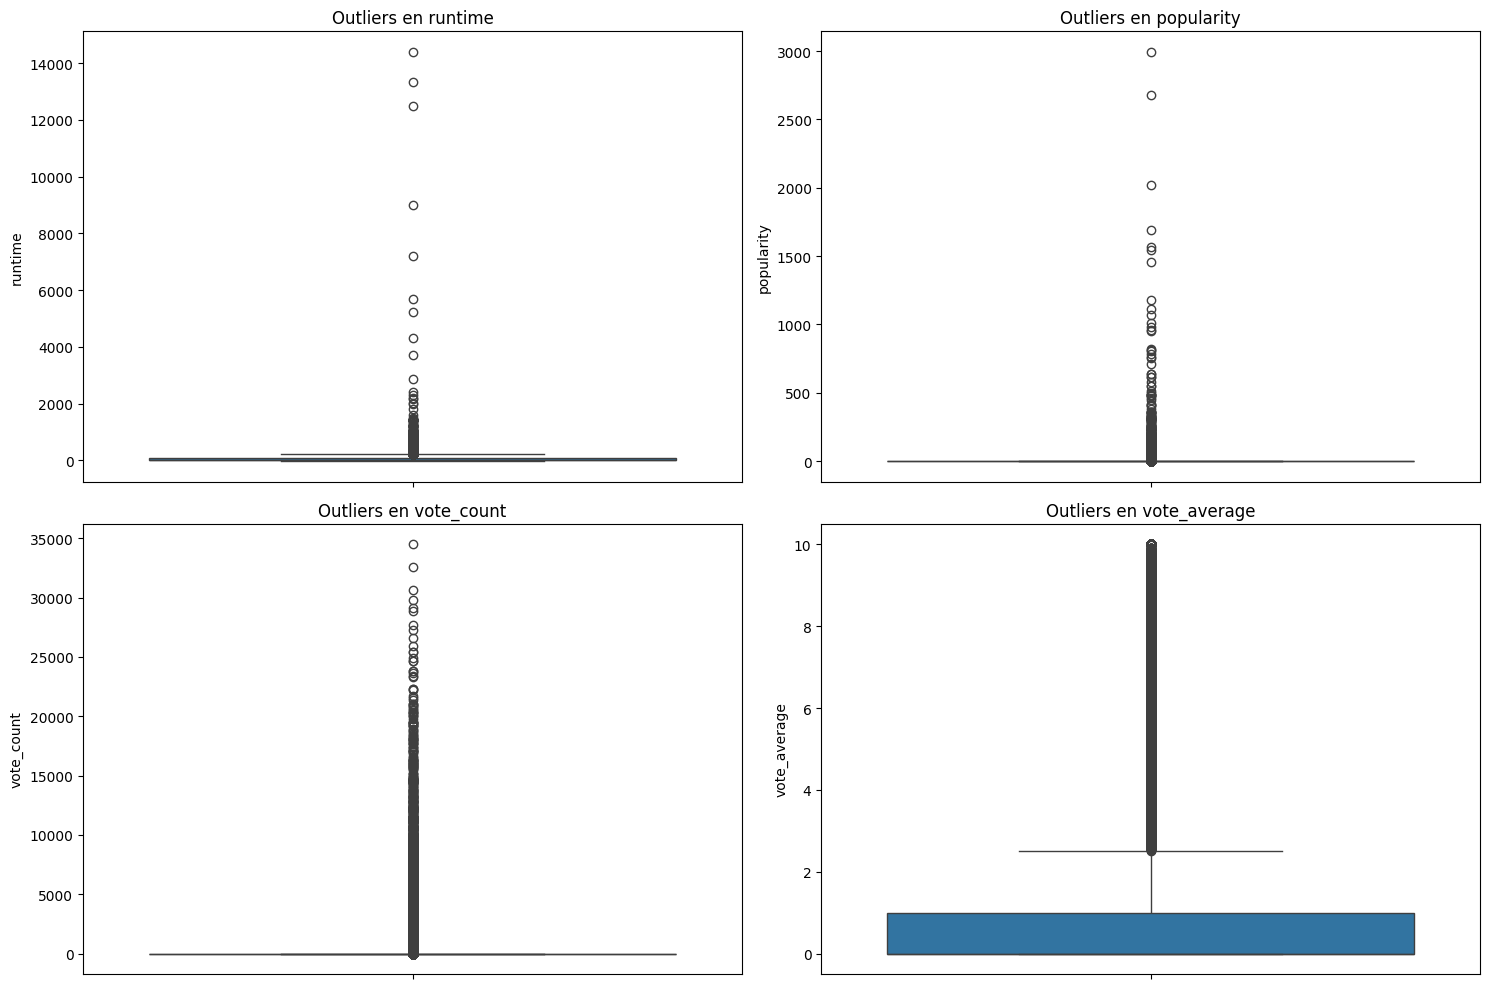

In [60]:
# Visualización de outliers con boxplots
cols_to_check = ['runtime', 'popularity', 'vote_count', 'vote_average']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=movies[col])
    plt.title(f'Outliers en {col}')

plt.tight_layout()
plt.show()

Además de identificar valores atípicos mediante boxplots, es importante  aplicar un tratamiento sobre estos valores para para reducir su impacto.

Algunas variables presentan valores extremadamente altos o bajos que pueden distorsionar el análisis. Para corregir esto, se limitaron esos valores extremos dentro de un rango razonable, utilizando como referencia los valores más bajos y más altos habituales del dataset. En particular, se recortaron los valores por debajo del percentil 1 y por encima del percentil 99.

Este enfoque permite reducir el impacto de valores extremos sin eliminar observaciones, manteniendo la mayor cantidad de información posible del dataset.

In [71]:
# Tratamiento de outliers
def cap_outliers(df, col):
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    return df

for col in ['runtime', 'vote_count', 'vote_average']:
    movies_filtered = cap_outliers(movies_filtered, col)

In [72]:
print(movies_filtered[['runtime','vote_count']].describe())

            runtime    vote_count
count  18086.000000  18086.000000
mean     101.668694    999.203825
std       23.620650   1931.811662
min        7.000000    102.000000
25%       91.000000    160.000000
50%      100.000000    296.000000
75%      113.000000    827.000000
max      173.000000  12218.427500


### 5.3 Filtrado por relevancia

Para que el modelo de Machine Learning aprenda patrones significativos, filtramos el dataset para incluir solo películas con más de 100 votos. Esto garantiza que el `vote_average` sea una métrica estable.

Dimensiones originales: (1406601, 25)
Dimensiones tras filtrado (>100 votos): (18080, 25)


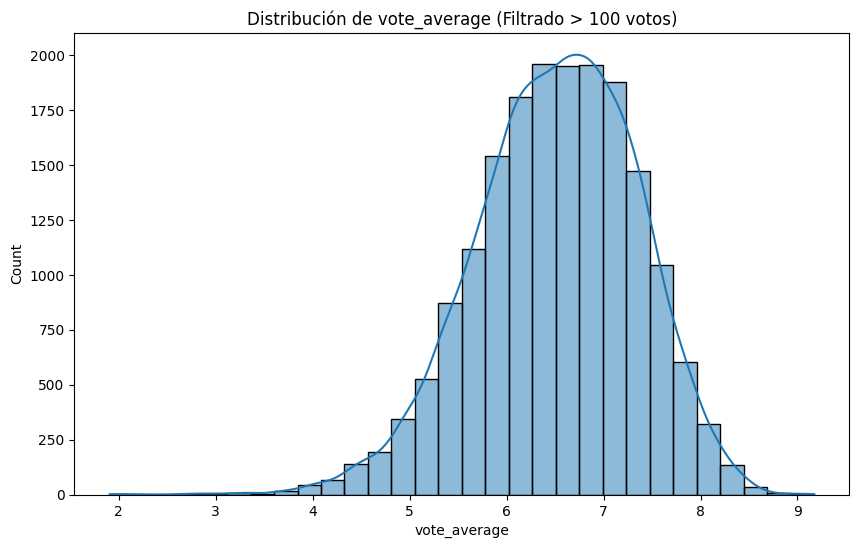

In [77]:
# Filtrado de películas con pocos votos + eliminación de contenido adulto
movies_filtered = movies[(movies['vote_count'] > 100) & (movies['adult'] == False)].copy()
print(f"Dimensiones originales: {movies.shape}")
print(f"Dimensiones tras filtrado (>100 votos): {movies_filtered.shape}")

# Verificamos la nueva distribución de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(movies_filtered['vote_average'], bins=30, kde=True)
plt.title('Distribución de vote_average (Filtrado > 100 votos)')
plt.show()

# 6. Preprocesamiento e Ingeniería de Funciones

En esta fase preparamos los datos para el análisis de componentes principales (PCA). Definimos el problema supervisado y realizamos la ingeniería de funciones necesaria.

### 6.1 Definición del Problema de Aprendizaje Supervisado

Nuestro objetivo es preparar las variables predictoras para estimar el `vote_average` de una película. Filtramos las variables que no aportan información predictiva (identificadores, nombres, slogans) y nos enfocamos en metadatos como géneros, idiomas y métricas de producción.

Se plantea un escenario inspirado en plataformas de streaming como Netflix, donde se dispone de información de películas antes de su estreno. En este contexto, el objetivo es predecir el vote_average que tendrá una película a partir de sus características previas al lanzamiento, tales como género, presupuesto, duración, idioma o país de producción.

Este enfoque tiene aplicaciones reales en la industria, como la toma de decisiones sobre adquisición de contenido, priorización en catálogos o estimación del engagement esperado.

A partir de esta definición, se excluyen variables que no estarían disponibles en el momento previo al estreno o que podrían introducir sesgo de información. Por ejemplo, la variable popularity no se considera, ya que es calculada en función de la interacción de los usuarios una vez que la película ya fue lanzada.

De esta manera, se asegura que el modelo utilice únicamente información disponible en un escenario realista de predicción previa al estreno.

In [91]:
# Selección de columnas iniciales y generación de variables temporales
features_cols = ['genres', 'original_language', 'production_companies', 'production_countries',
                 'runtime', 'budget', 'revenue']

# Nota: Usamos columns que ya fueron pre-procesadas en pasos anteriores si es necesario.
target = 'vote_average'

df_ml = movies_filtered[features_cols + [target]].copy()

df_ml.head()

,genres,original_language,production_companies,production_countries,runtime,budget,revenue,vote_average
0,"[Action, Science Fiction, Adventure]",en,"Legendary Pictures, Syncopy, Warner Bros. Pict...","[United Kingdom, United States of America]",148,160000000,825532764,8.364
1,"[Adventure, Drama, Science Fiction]",en,"Legendary Pictures, Syncopy, Lynda Obst Produc...","[United Kingdom, United States of America]",169,165000000,701729206,8.417
2,"[Drama, Action, Crime, Thriller]",en,"DC Comics, Legendary Pictures, Syncopy, Isobel...","[United Kingdom, United States of America]",152,185000000,1004558444,8.512
3,"[Action, Adventure, Fantasy, Science Fiction]",en,"Dune Entertainment, Lightstorm Entertainment, ...","[United States of America, United Kingdom]",162,237000000,2923706026,7.573
4,"[Science Fiction, Action, Adventure]",en,Marvel Studios,[United States of America],143,220000000,1518815515,7.710


Se simplificaron algunas variables categóricas que presentaban una gran cantidad de valores posibles, como el idioma y el país de producción.
En particular, las variables original_language y production_countries presentaban una gran cantidad de categorías distintas.

Para abordar este problema, en lugar de trabajar con todas las categorías originales, se agruparon en clases más generales (por ejemplo, inglés vs. otros idiomas, o Estados Unidos vs. resto del mundo), con el objetivo de facilitar el modelado y evitar generar una gran cantidad de variables.
Esta simplificación permite mantener información relevante sobre el origen de las películas, al mismo tiempo que reduce la dimensionalidad del dataset y mejora la interpretabilidad de los resultados.


In [101]:
# Idioma
df_ml['is_english'] = df_ml['original_language'].apply(
    lambda x: 1 if x == 'en' else 0
)

# País
df_ml['is_usa'] = df_ml['production_countries'].apply(
    lambda x: 1 if 'United States of America' in str(x) else 0
)

df_ml.drop(columns=['original_language', 'production_countries'], inplace=True)

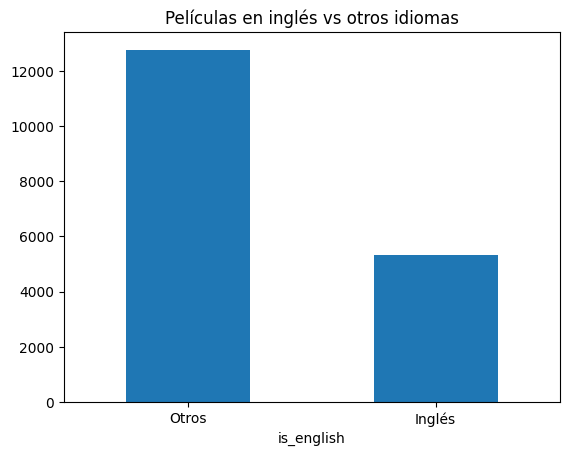

In [102]:
df_ml['is_english'].value_counts().plot(kind='bar')
plt.title("Películas en inglés vs otros idiomas")
plt.xticks([0,1], ['Otros', 'Inglés'], rotation=0)
plt.show()

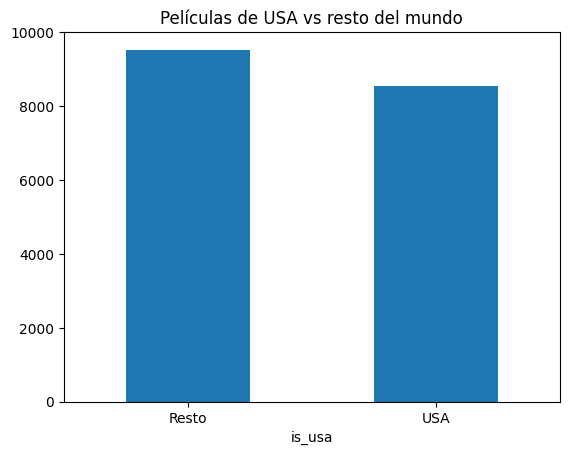

In [103]:
df_ml['is_usa'].value_counts().plot(kind='bar')
plt.title("Películas de USA vs resto del mundo")
plt.xticks([0,1], ['Resto', 'USA'], rotation=0)
plt.show()

### 6.2 Manejo de Variables Categóricas y Train/Test Split

Para evitar el sesgo de información (data leakage), realizamos la división en conjuntos de entrenamiento y prueba antes de aplicar transformaciones que dependan de la distribución de los datos.

In [104]:
from sklearn.model_selection import train_test_split

# Simplificamos las listas (tomamos el primer elemento para el análisis)
def clean_list_col(x):
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return 'Unknown'

for col in ['genres', 'production_companies']:
    df_ml[col] = df_ml[col].apply(clean_list_col)

# División Train/Test
X = df_ml.drop(columns=[target])
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14464, 7)
X_test shape: (3616, 7)


### 6.3 Codificación (Encoding) y Escalado

Aplicamos One-Hot Encoding a las variables categóricas y estandarizamos las numéricas mediante un Pipeline de Scikit-Learn.

In [105]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identificamos tipos de columnas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Definimos transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinamos en un Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Ajustamos y transformamos
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Obtenemos nombres de columnas para el DataFrame resultante
feature_names = (num_cols +
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot'].get_feature_names_out(cat_cols).tolist())

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
X_train_df.head()

,runtime,budget,revenue,is_english,is_usa,genres_Unknown,production_companies_Unknown
0,-0.079786,0.191396,-0.035024,0.642799,-0.948372,1.0,1.0
1,-0.667976,-0.428151,-0.309419,0.642799,-0.948372,1.0,1.0
2,-0.079786,-0.428151,-0.309419,0.642799,1.054439,1.0,1.0
3,1.684784,-0.428151,-0.309419,-1.555697,-0.948372,1.0,1.0
4,0.351553,-0.428151,-0.309419,-1.555697,-0.948372,1.0,1.0


# 7. Reducción de Dimensionalidad

Finalmente, aplicamos técnicas de selección de funciones (basadas en correlación) y reducción de dimensionalidad (PCA) para simplificar nuestro conjunto de datos manteniendo la mayor parte de la información.

### 7.1 Análisis de Correlación

Identificamos variables con baja correlación con el objetivo o alta correlación entre sí (redundancia).

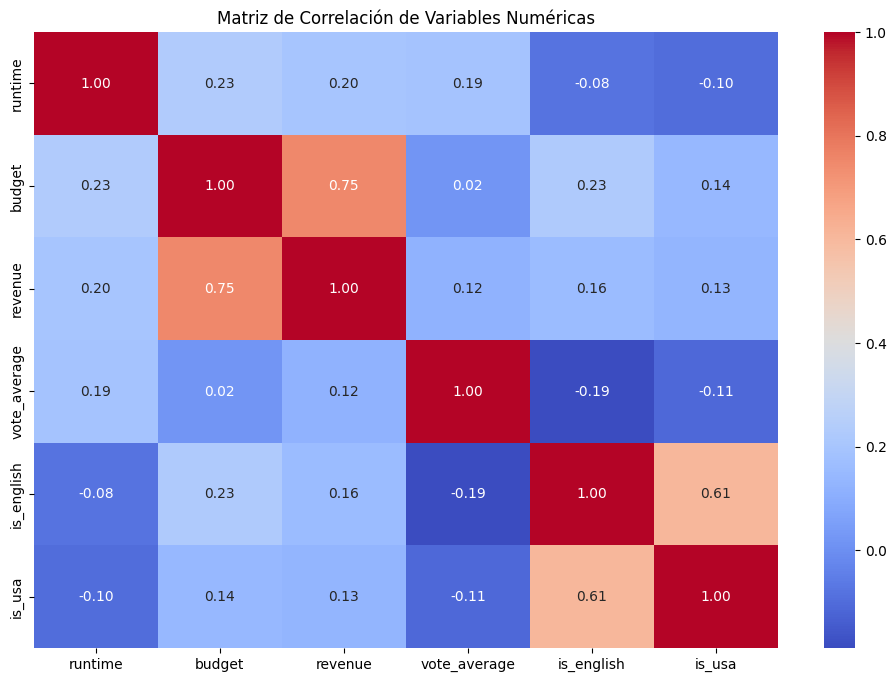

In [106]:
# Matriz de correlación para variables numéricas originales
plt.figure(figsize=(12, 8))
sns.heatmap(df_ml.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### 7.2 Aplicación de PCA (Análisis de Componentes Principales)

Reducimos el espacio de características procesado (que suele crecer debido al One-Hot Encoding) a un conjunto de componentes principales.

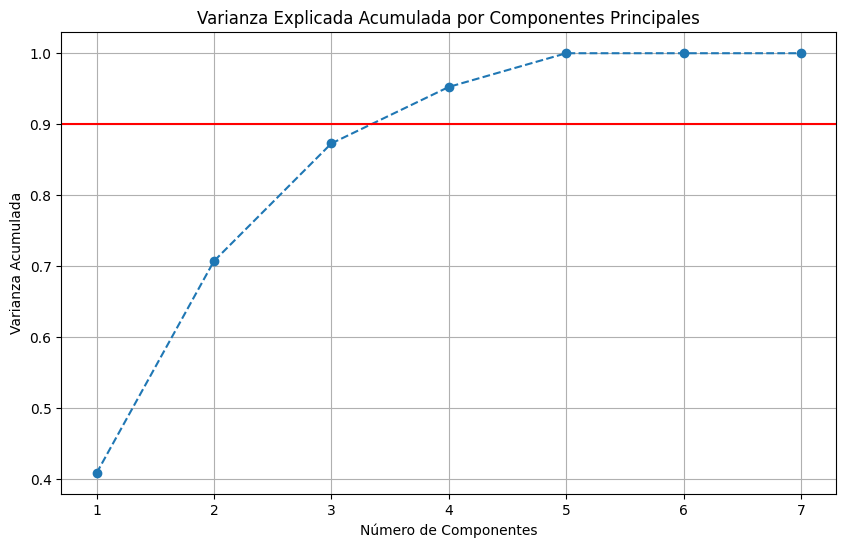

Número de componentes para explicar el 90% de la varianza: 4


In [107]:
from sklearn.decomposition import PCA

# Aplicamos PCA sin reducir inicialmente para ver la varianza explicada
pca = PCA()
X_pca = pca.fit_transform(X_train_df)

# Varianza acumulada
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='-')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid()
plt.show()

# Seleccionamos componentes que expliquen el 90% de la varianza
n_components_90 = np.argmax(explained_variance_ratio >= 0.9) + 1
print(f"Número de componentes para explicar el 90% de la varianza: {n_components_90}")

### 7.3 Conclusión de la Preparación de Datos

Hemos transformado el dataset original de películas de TMDB en un conjunto de componentes principales listos para ser utilizados. El proceso incluyó:
1. Filtrado por relevancia (>100 votos).
2. Clasificación y manejo de nulos.
3. Ingeniería de variables temporales.
4. Codificación y Escalado.
5. Reducción de dimensionalidad mediante PCA, logrando representar la mayoría de la información con un número reducido de variables sintéticas.

### 7.3 Evaluación de Resultados: Análisis de 'Loadings'

Para interpretar los componentes principales, analizamos la contribución (pesos) de las variables originales a los dos primeros componentes.

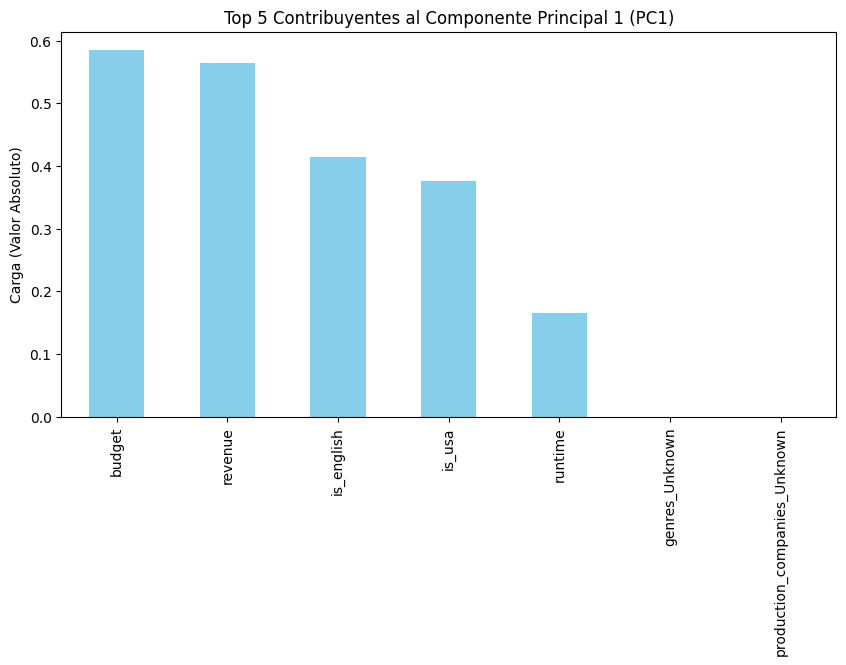

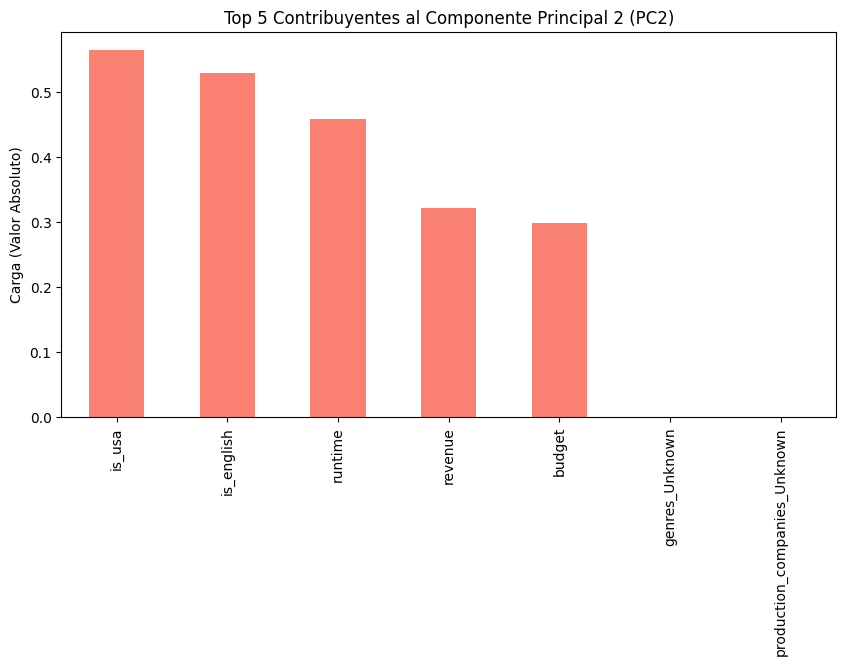

In [112]:
# Obtenemos los pesos (loadings) de los componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

# Visualizamos las 5 variables que más contribuyen al PC1
plt.figure(figsize=(10, 5))
loadings['PC1'].abs().sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Top 5 Contribuyentes al Componente Principal 1 (PC1)')
plt.ylabel('Carga (Valor Absoluto)')
plt.show()

# Visualizamos las 5 variables que más contribuyen al PC2
plt.figure(figsize=(10, 5))
loadings['PC2'].abs().sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title('Top 5 Contribuyentes al Componente Principal 2 (PC2)')
plt.ylabel('Carga (Valor Absoluto)')
plt.show()

### 7.4 Visualización del Espacio de Características Reducido

Graficamos las películas en el nuevo espacio definido por PC1 y PC2. Coloreamos los puntos por el `vote_average` para observar si existe alguna agrupación o tendencia visual clara en la distribución de las puntuaciones.

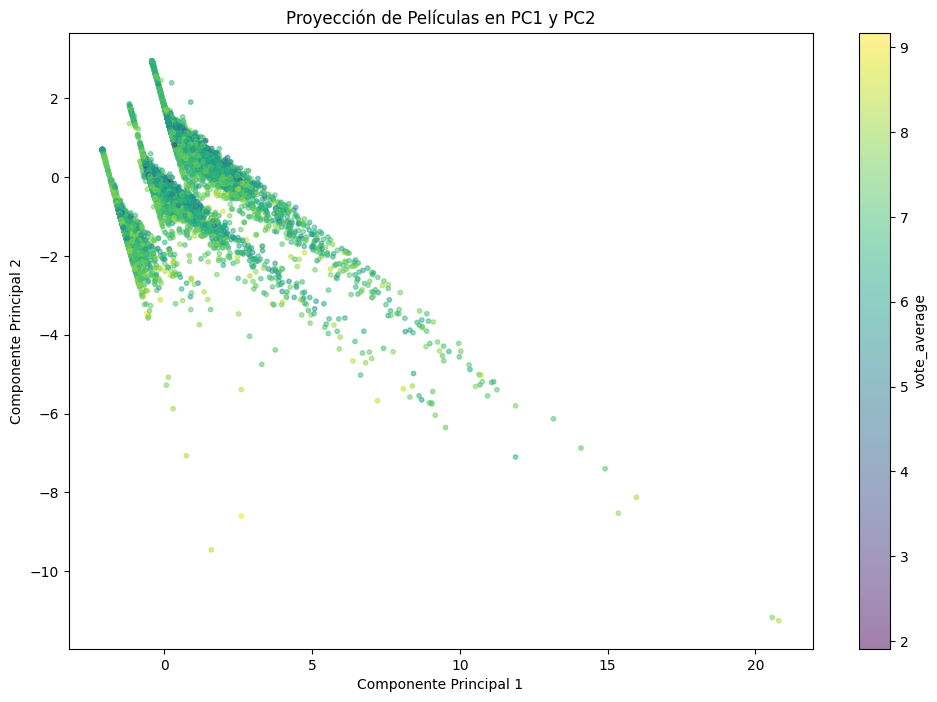

In [109]:
# Scatter plot de PC1 vs PC2 coloreado por la variable objetivo
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='vote_average')
plt.title('Proyección de Películas en PC1 y PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# 8. Conclusiones Finales

Tras completar el análisis y preparación de los datos de TMDB, podemos concluir:

1. **Estructura del Dataset:** El conjunto de datos presenta una alta dimensionalidad y una gran cantidad de variables categóricas. La limpieza y extracción del metadato principal permitió simplificar el análisis manteniendo la información clave.
2. **Calidad de Datos:** La clasificación de nulos permitió entender la naturaleza de los datos faltantes (MAR/MNAR). El filtrado por `vote_count > 100` fue fundamental para garantizar que la variable objetivo sea robusta.
3. **Representatividad mediante PCA:** El análisis demostró que es posible reducir drásticamente el número de variables (logrando explicar el 90% de la varianza) utilizando componentes principales, lo cual optimiza el dataset para futuras etapas de modelado.
4. **Visualización:** La proyección en el espacio de componentes principales permite analizar la distribución general de las películas. Sin embargo, no se observan agrupamientos claramente definidos según el vote_average, lo que sugiere que las variables consideradas no separan de forma evidente las películas en función de su puntuación.